# Nondimensional two-element Windkessel model

**Leif Rune Hellevik**  
Department of Structural Engineering, Norwegian University of Science and
Technology (NTNU), Trondheim, Norway  
[GitHub](https://github.com/lrhgit)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lrhgit/windkessel_nondim/blob/main/windkessel_nondimensional_analysis.ipynb)

<details>
<summary><strong>Using this notebook in Google Colab</strong></summary>

1. Select **File → Save a copy in Drive**.
2. Select **Runtime → Run all**.
3. Modify $\Pi_R$ and $\Pi_T$, then rerun the relevant cells.
4. If variables become inconsistent, select
   **Runtime → Restart session and run all**.

No local installation is required. Changes made in Colab are not written
back to the original GitHub repository.

New to Colab? See Google's
[Introduction to Colab](https://colab.research.google.com/notebooks/intro.ipynb).

</details>

The dimensional two-element Windkessel equation is
$$
C\frac{dp}{dt}+\frac{p}{R}=q(t).
$$
We use the mean flow $q_m$ as the flow scale, a reference pressure $p_c$, and dimensionless cardiac time
$$
\tau=\frac{t}{T_h}.
$$
With
$$
p^*=\frac{p}{p_c},\qquad q^*=\frac{q}{q_m},\qquad
\Pi_R=\frac{Rq_m}{p_c},\qquad
\Pi_T=\frac{T_h}{RC},
$$
substitution into the dimensional equation first gives
$$
\frac{RC}{T_h}\frac{dp^*}{d\tau}+p^*=\frac{Rq_m}{p_c}q^*(\tau),
$$
or, directly in terms of the two dimensionless groups,
$$
\frac{1}{\Pi_T}\frac{dp^*}{d\tau}+p^*=\Pi_R q^*(\tau).
$$
This form shows the two roles separately: $\Pi_T^{-1}=RC/T_h$ multiplies the transient term, while $\Pi_R$ sets the pressure response to the inflow. Multiplying by $\Pi_T$ and isolating the derivative gives the form used in the numerical solution,
$$
\frac{dp^*}{d\tau}=\Pi_T\left(\Pi_Rq^*(\tau)-p^*\right).
$$

The inflow is represented by a simple periodic systolic pulse: rapid upstroke, rounded peak, decay to zero at end systole, and zero flow during diastole. The purpose is to study how $\Pi_R$ controls the pressure scale and how $\Pi_T$ controls the response within a cardiac cycle. Using $\tau$ keeps the horizontal time scale fixed while $RC$ is varied.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True

## 1. Idealized aortic-flow input

We use dimensionless cardiac time
$$
\tau=\frac{t}{T_h}.
$$
For a periodic waveform, $\tau_c=\tau\bmod 1$ denotes time within the current cardiac cycle. The modulo operation removes completed cycles; for example, $\tau=2.3$ gives $\tau_c=0.3$.

Let $\tau_s=T_s/T_h$ be the fraction of the cycle occupied by systole. With peak flow $q_{\max}$ in $\mathrm{mL/s}$, prescribe
$$
q(\tau)=
\begin{cases}
q_{\max}\sin^\alpha\!\left(\pi\tau_c/\tau_s\right), & 0\leq\tau_c<\tau_s,\\
0, & \tau_s\leq\tau_c<1.
\end{cases}
$$
The mean flow over one cycle is evaluated numerically,
$$
q_m=\int_0^1 q(\tau)\,d\tau,
$$
and the dimensionless inflow is
$$
q^*(\tau)=\frac{q(\tau)}{q_m},\qquad \overline{q^*}=1.
$$

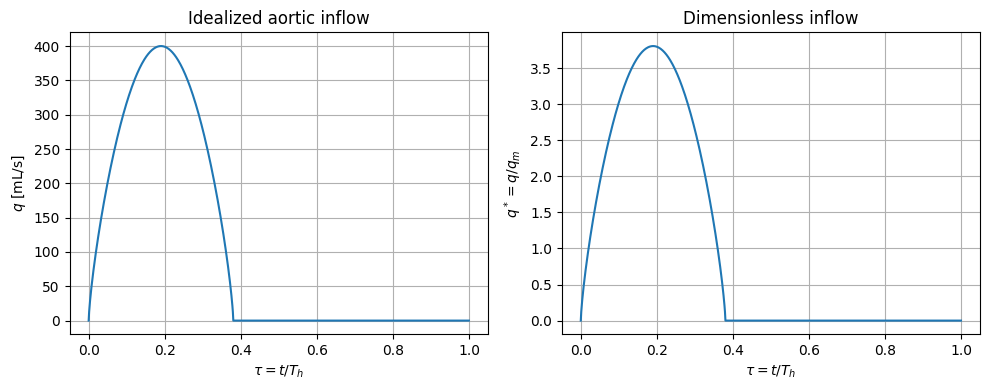

Mean flow q_m: 105.12 mL/s
Numerical mean q*: 1.000


In [2]:
def q(tau, q_max=400.0, tau_s=0.38, alpha=0.75):
    """Aortic flow q(tau) in mL/s."""
    tau = np.asarray(tau, dtype=float)

    # Map any time to its position within the current cardiac cycle:
    # for example, tau = 2.3 becomes tau_cycle = 0.3.
    tau_cycle = tau % 1.0
    systole = tau_cycle < tau_s
    pulse = np.sin(np.pi * tau_cycle / tau_s).clip(min=0.0)**alpha
    flow = np.where(systole, q_max * pulse, 0.0)

    return flow.item() if flow.ndim == 0 else flow


def q_m(q_max=400.0, tau_s=0.38, alpha=0.75):
    """Mean flow over one cardiac cycle, in mL/s."""
    mean_flow, _ = quad(
        lambda tau: q(tau, q_max=q_max, tau_s=tau_s, alpha=alpha),
        0.0,
        1.0,
    )
    return mean_flow


def q_star(tau, q_max=400.0, tau_s=0.38, alpha=0.75):
    """Dimensionless flow q* = q/q_m."""
    return q(tau, q_max, tau_s, alpha) / q_m(q_max, tau_s, alpha)


# One cardiac cycle, without duplicating the endpoint tau = 1.
Nc = 800  # Number of time intervals per cardiac cycle
tau = np.arange(Nc) / Nc
q_max = 400.0  # mL/s
flow = q(tau, q_max=q_max)
flow_mean = q_m(q_max=q_max)
flow_star = q_star(tau, q_max=q_max)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(tau, flow)
axes[0].set(xlabel=r"$\tau=t/T_h$", ylabel=r"$q$ [mL/s]",
            title="Idealized aortic inflow")
axes[1].plot(tau, flow_star)
axes[1].set(xlabel=r"$\tau=t/T_h$", ylabel=r"$q^*=q/q_m$",
            title="Dimensionless inflow")
plt.tight_layout()
plt.show()

print(f"Mean flow q_m: {flow_mean:.2f} mL/s")
print(f"Numerical mean q*: {np.mean(flow_star):.3f}")

## 2. Solve the nondimensional ODE

For chosen $\Pi_R$ and $\Pi_T=T_h/(RC)$,
$$
\frac{dp^*}{d\tau}=\Pi_T\left(\Pi_Rq^*(\tau)-p^*\right).
$$

The general solution of a linear ODE is the sum of a homogeneous solution and a particular solution. Over a short step $\Delta\tau$, approximate the inflow as constant, $q^*(\tau)\approx q_n^*$.

For the homogeneous solution, remove the forcing term. Then
$$
\frac{dp_h^*}{d\tau}=-\Pi_Tp_h^*,
\qquad
\frac{dp_h^*}{p_h^*}=-\Pi_T\,d\tau,
$$
which integrates from $\tau_n$ to $\tau$ to give
$$
p_h^*(\tau)=A e^{-\Pi_T(\tau-\tau_n)}.
$$

To find a constant particular solution, set $p_p^*=K$. Since $dp_p^*/d\tau=0$, substitution into the ODE gives
$$
0=\Pi_T\left(\Pi_Rq_n^*-K\right),
$$
so $K=\Pi_Rq_n^*$. Hence, within the step,
$$
p^*(\tau)=\Pi_Rq_n^*+A e^{-\Pi_T(\tau-\tau_n)}.
$$
Using $p^*(\tau_n)=p_n^*$ to determine $A$, and evaluating at $\tau_{n+1}=\tau_n+\Delta\tau$, gives
$$
p_{n+1}^*=p_n^*e^{-\Pi_T\Delta\tau}
+\Pi_Rq_n^*\left(1-e^{-\Pi_T\Delta\tau}\right).
$$
Thus, the pressure equation is integrated exactly within each step; the approximation lies only in treating $q^*$ as constant over that short interval. Several cycles are simulated so that the initial transient decays before the final cycle is plotted.

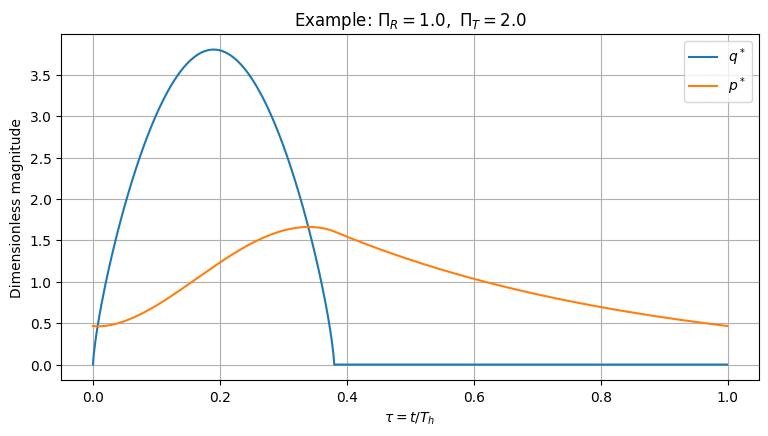

In [4]:
def solve_wk_nd(
    Pi_R=1.0,
    Pi_T=2.0,
    n_cycles=12,
    Nc=800,
    q_max=400.0,
    tau_s=0.38,
    alpha=0.75,
    p0=0.0,
):
    """Solve the nondimensional two-element Windkessel model.

    Parameters
    ----------
    Pi_R : float
        Dimensionless resistance parameter, R*q_m/p_c.
    Pi_T : float
        Ratio of cardiac period to Windkessel time, T_h/(R*C).
    n_cycles : int
        Number of cardiac cycles to simulate. The initial cycles allow
        the transient caused by p0 to decay.
    Nc : int
        Number of time intervals per cardiac cycle.
    q_max : float
        Peak dimensional inflow in mL/s. It cancels when q* is formed.
    tau_s : float
        Fraction of the cardiac cycle occupied by systole.
    alpha : float
        Exponent controlling the shape of the inflow pulse.
    p0 : float
        Initial dimensionless pressure.

    Returns
    -------
    tau : ndarray
        Dimensionless cardiac time, tau = t/T_h.
    qstar : ndarray
        Dimensionless inflow, q* = q/q_m.
    pstar : ndarray
        Dimensionless Windkessel pressure.
    """
    d_tau = 1.0 / Nc
    tau = np.arange(n_cycles * Nc + 1) * d_tau
    qstar = q_star(tau, q_max=q_max, tau_s=tau_s, alpha=alpha)

    pstar = np.zeros_like(tau)
    pstar[0] = p0

    # Exact pressure-decay factor over one time interval.
    p_decay = np.exp(-Pi_T * d_tau)
    for n in range(len(tau) - 1):
        pstar[n + 1] = (
            pstar[n] * p_decay
            + Pi_R * qstar[n] * (1.0 - p_decay)
        )

    return tau, qstar, pstar


Pi_R, Pi_T = 1.0, 2.0
tau, qstar, pstar = solve_wk_nd(Pi_R=Pi_R, Pi_T=Pi_T)

# Select the final complete cardiac cycle and omit its duplicated endpoint.
mask = (tau >= tau[-1] - 1.0) & (tau < tau[-1])
tau_plot = tau[mask] % 1.0

plt.plot(tau_plot, qstar[mask], label=r"$q^*$")
plt.plot(tau_plot, pstar[mask], label=r"$p^*$")
plt.xlabel(r"$\tau=t/T_h$")
plt.ylabel("Dimensionless magnitude")
plt.title(fr"Example: $\Pi_R={Pi_R},\ \Pi_T={Pi_T}$")
plt.legend()
plt.show()

### Comparison with SciPy's Runge–Kutta solver

As an independent check, we integrate the original time-dependent ODE with `scipy.integrate.solve_ivp` using its adaptive explicit Runge–Kutta method (RK45). The solution is evaluated on the same time grid as the exponential-step scheme. The two solutions should converge as the time step is refined.

Maximum absolute difference: 3.413e-03
Mean absolute difference:    1.490e-03


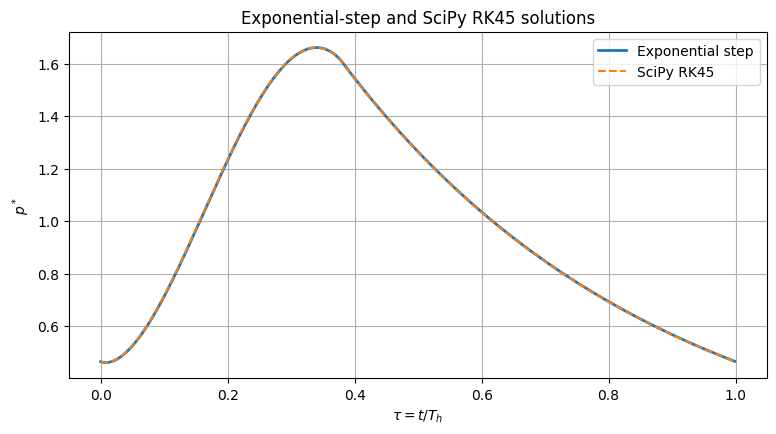

In [6]:
from scipy.integrate import solve_ivp


def solve_wk_rk45(
    Pi_R=1.0,
    Pi_T=2.0,
    n_cycles=12,
    Nc=800,
    q_max=400.0,
    tau_s=0.38,
    alpha=0.75,
    p0=0.0,
):
    """Solve the tau-based Windkessel ODE with SciPy's adaptive RK45."""
    d_tau = 1.0 / Nc
    tau_eval = np.arange(n_cycles * Nc + 1) * d_tau
    mean_flow = q_m(q_max=q_max, tau_s=tau_s, alpha=alpha)

    def rhs(tau, pstar):
        qstar = q(tau, q_max=q_max, tau_s=tau_s, alpha=alpha) / mean_flow
        return [Pi_T * (Pi_R * qstar - pstar[0])]

    sol = solve_ivp(
        rhs,
        (tau_eval[0], tau_eval[-1]),
        [p0],
        method="RK45",
        t_eval=tau_eval,
        max_step=d_tau,
        rtol=1e-9,
        atol=1e-11,
    )
    return sol.t, sol.y[0]


# Compare both methods on the same cardiac-time grid.
Pi_R_cmp, Pi_T_cmp = 1.0, 2.0
tau_exp, _, p_exp = solve_wk_nd(Pi_R=Pi_R_cmp, Pi_T=Pi_T_cmp)
tau_rk, p_rk = solve_wk_rk45(Pi_R=Pi_R_cmp, Pi_T=Pi_T_cmp)

mask_cmp = (tau_exp >= tau_exp[-1] - 1.0) & (tau_exp < tau_exp[-1])
error = np.abs(p_exp[mask_cmp] - p_rk[mask_cmp])
print(f"Maximum absolute difference: {error.max():.3e}")
print(f"Mean absolute difference:    {error.mean():.3e}")

plt.plot(tau_exp[mask_cmp] % 1.0, p_exp[mask_cmp],
         label="Exponential step", lw=2)
plt.plot(tau_rk[mask_cmp] % 1.0, p_rk[mask_cmp], "--",
         label="SciPy RK45", lw=1.5)
plt.xlabel(r"$\tau=t/T_h$")
plt.ylabel(r"$p^*$")
plt.title("Exponential-step and SciPy RK45 solutions")
plt.legend()
plt.show()

## 3. Effect of $\Pi_R$

At fixed $\Pi_T$, $\Pi_R$ controls the dimensionless pressure level. The 2WK model is linear, so $p^*$ scales linearly with $\Pi_R$.

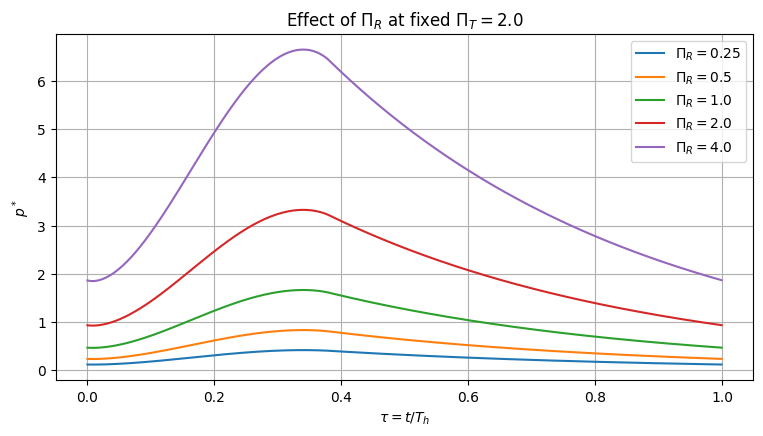

In [7]:
Pi_R_values = [0.25, 0.5, 1.0, 2.0, 4.0]
Pi_T = 2.0

for Pi_R in Pi_R_values:
    tau, qstar, pstar = solve_wk_nd(Pi_R=Pi_R, Pi_T=Pi_T)

    # Final complete cycle, without the duplicated endpoint.
    mask = (tau >= tau[-1] - 1.0) & (tau < tau[-1])
    tau_cycle = tau[mask] % 1.0
    plt.plot(tau_cycle, pstar[mask], label=fr"$\Pi_R={Pi_R}$")

plt.xlabel(r"$\tau=t/T_h$")
plt.ylabel(r"$p^*$")
plt.title(fr"Effect of $\Pi_R$ at fixed $\Pi_T={Pi_T}$")
plt.legend()
plt.show()

## 4. Effect of $\Pi_T=T_h/(RC)$

This controls the dynamics relative to the cardiac cycle.

- Small $\Pi_T$: $RC$ is long compared with the cardiac period; the reservoir changes slowly and smooths the pulsatile input.
- Large $\Pi_T$: $RC$ is short relative to the cycle; pressure responds and decays more rapidly.

The reciprocal $RC/T_h=1/\Pi_T$ is an equally valid group.

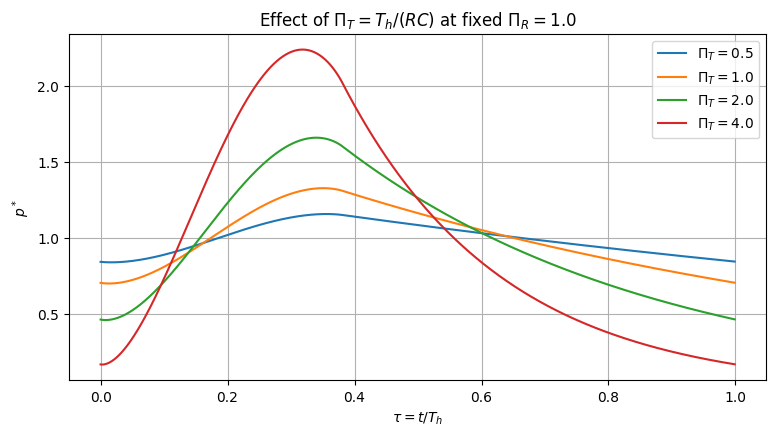

In [8]:
Pi_T_values = [0.5, 1.0, 2.0, 4.0]
Pi_R = 1.0

for Pi_T in Pi_T_values:
    tau, qstar, pstar = solve_wk_nd(Pi_R=Pi_R, Pi_T=Pi_T)

    # The same cardiac-time interval is used for every value of Pi_T.
    mask = (tau >= tau[-1] - 1.0) & (tau < tau[-1])
    tau_cycle = tau[mask] % 1.0
    plt.plot(tau_cycle, pstar[mask], label=fr"$\Pi_T={Pi_T}$")

plt.xlabel(r"$\tau=t/T_h$")
plt.ylabel(r"$p^*$")
plt.title(fr"Effect of $\Pi_T=T_h/(RC)$ at fixed $\Pi_R={Pi_R}$")
plt.legend()
plt.show()

## 5. Connect to dimensional parameters

For resistance $R$ in $\mathrm{mmHg\,s/mL}$, compliance $C$ in $\mathrm{mL/mmHg}$, mean flow $q_m$ in $\mathrm{mL/s}$, reference area $A_c$, density $\rho$, and cardiac period $T_h$,
$$
p_c=\rho\left(\frac{q_m}{A_c}\right)^2,\qquad
\Pi_R=\frac{Rq_m}{p_c}=\frac{RA_c^2}{\rho q_m},\qquad
\Pi_T=\frac{T_h}{RC}.
$$
The product $RC$ has units of seconds. The helper below accepts these convenient cardiovascular units and converts internally to SI.

In [9]:
MMHG_TO_PA = 133.322
ML_TO_M3 = 1e-6


def dimensional_to_pi(
    R_mmhg_s_ml=1.0,
    C_ml_mmhg=1.5,
    A_cm2=4.5,
    rho=1060.0,
    q_max_ml_s=400.0,
    tau_s=0.38,
    alpha=0.75,
    heart_period_s=0.8,
):
    """Convert convenient cardiovascular units to Pi_R and Pi_T."""
    R = R_mmhg_s_ml * MMHG_TO_PA / ML_TO_M3
    C = C_ml_mmhg * ML_TO_M3 / MMHG_TO_PA
    A = A_cm2 * 1e-4

    q_mean_ml_s = q_m(q_max=q_max_ml_s, tau_s=tau_s, alpha=alpha)
    q_mean = q_mean_ml_s * ML_TO_M3

    pc = rho * (q_mean / A)**2
    Pi_R = R * q_mean / pc
    RC_s = R * C
    Pi_T = heart_period_s / RC_s

    return dict(
        R=R,
        C=C,
        A=A,
        q_m_ml_s=q_mean_ml_s,
        pc=pc,
        Pi_R=Pi_R,
        RC_s=RC_s,
        Pi_T=Pi_T,
    )


pars = dimensional_to_pi()
for key, value in pars.items():
    print(f"{key:>10s} = {value:.5g}")

         R = 1.3332e+08
         C = 1.1251e-08
         A = 0.00045
  q_m_ml_s = 105.12
        pc = 57.846
      Pi_R = 242.28
      RC_s = 1.5
      Pi_T = 0.53333


## 6. Change dimensional parameters, solve the same nondimensional model

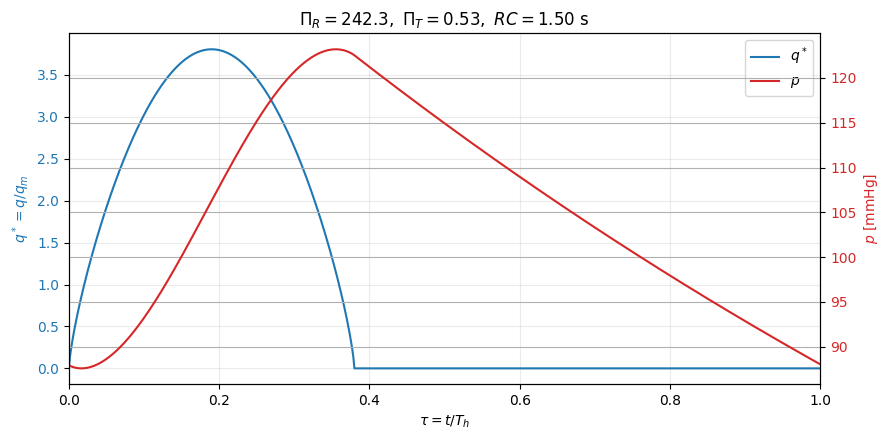

In [10]:
pars = dimensional_to_pi(
    R_mmhg_s_ml=1.0,      # peripheral resistance [mmHg s/mL]
    C_ml_mmhg=1.5,        # compliance [mL/mmHg]
    A_cm2=4.5,            # characteristic area [cm^2]
    rho=1060.0,           # blood density [kg/m^3]
    q_max_ml_s=400.0,     # peak inflow [mL/s]
    tau_s=0.38,           # systolic fraction of one cardiac cycle [-]
    alpha=0.75,           # inflow-shape parameter [-]
    heart_period_s=0.8,   # cardiac-cycle duration T_h [s]
)

tau, qstar, pstar = solve_wk_nd(
    Pi_R=pars["Pi_R"],
    Pi_T=pars["Pi_T"],
    q_max=400.0,
    tau_s=0.38,
    alpha=0.75,
)

# Select the last cardiac cycle and express time within it as 0 <= tau < 1.
mask = (tau >= tau[-1] - 1.0) & (tau < tau[-1])
tau_cycle = tau[mask] % 1.0

# Convert p* back to dimensional pressure.
p_mmhg = pstar[mask] * pars["pc"] / MMHG_TO_PA

fig, ax_q = plt.subplots()
ax_p = ax_q.twinx()
line_q, = ax_q.plot(tau_cycle, qstar[mask], color="tab:blue", label=r"$q^*$")
line_p, = ax_p.plot(tau_cycle, p_mmhg, color="tab:red", label=r"$p$")
ax_q.set_xlabel(r"$\tau=t/T_h$")
ax_q.set_ylabel(r"$q^*=q/q_m$", color="tab:blue")
ax_p.set_ylabel(r"$p$ [mmHg]", color="tab:red")
ax_q.tick_params(axis="y", labelcolor="tab:blue")
ax_p.tick_params(axis="y", labelcolor="tab:red")
ax_q.set_xlim(0, 1)
ax_q.grid(alpha=0.25)
ax_q.legend([line_q, line_p], [line_q.get_label(), line_p.get_label()], loc="upper right")
ax_q.set_title(
    fr"$\Pi_R={pars['Pi_R']:.1f},\ \Pi_T={pars['Pi_T']:.2f},\ RC={pars['RC_s']:.2f}\ \mathrm{{s}}$"
)
plt.tight_layout()

## 7. Mean-pressure check

For a periodic steady state, averaging

$$
C\frac{dp}{dt}+\frac{p}{R}=q
$$

over one cardiac cycle eliminates the derivative term because the pressure returns to the same value. With the cycle-mean flow $q_m$,

$$
\bar p=R q_m,
\qquad
\overline{p^*}=\frac{R q_m}{p_c}=\Pi_R.
$$

Thus $\Pi_R$ is also the mean dimensionless pressure for this scaling. This provides a useful numerical check of the periodic solution.

In [11]:
Pi_R, Pi_T = 2.0, 1.5
tau, qstar, pstar = solve_wk_nd(Pi_R=Pi_R, Pi_T=Pi_T)

# The mask selects one complete cardiac cycle: tau[-1]-1 <= tau < tau[-1].
mask = (tau >= tau[-1] - 1.0) & (tau < tau[-1])

print("Mean q* over final cycle :", np.mean(qstar[mask]))
print("Mean p* over final cycle :", np.mean(pstar[mask]))
print("Expected mean p* = Pi_R :", Pi_R)

Mean q* over final cycle : 0.9999587943789265
Mean p* over final cycle : 1.9999175478271147
Expected mean p* = Pi_R : 2.0
